Ejercicio 6

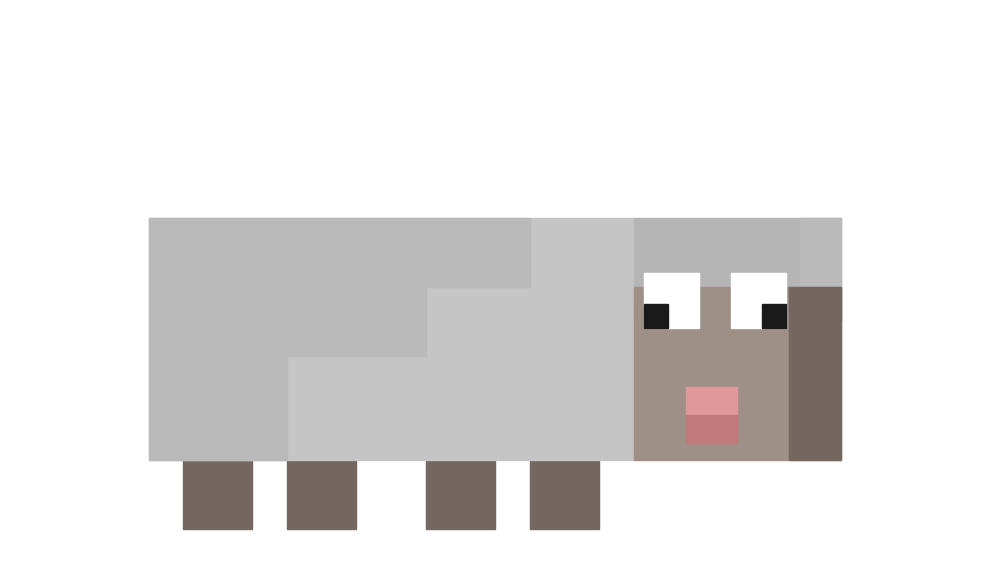

In [14]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 28)
ax.set_ylim(0, 16)
ax.set_aspect('equal')
ax.axis('off')

# ── Colores ────────────────────────────────────────────────────────────────────
WOOL        = '#C5C5C5'   # lana cuerpo base
WOOL_SH     = '#BABABA'   # sombra escalonada (ligera)
WOOL_HEAD   = '#B5B5B5'   # lana cabeza (ligeramente más oscura que el cuerpo)
SKIN        = '#9E9087'
SKIN_DARK   = '#736760'
EYE_WHITE   = '#FFFFFF'
EYE_IRIS    = '#1A1A1A'
LIP_TOP     = '#E09898'
LIP_BOT     = '#C27A7A'

# ── Patas ──────────────────────────────────────────────────────────────────────
ax.add_patch(patches.Rectangle((5,  1), 2, 2.5, color=SKIN_DARK))
ax.add_patch(patches.Rectangle((8,  1), 2, 2.5, color=SKIN_DARK))
ax.add_patch(patches.Rectangle((12, 1), 2, 2.5, color=SKIN_DARK))
ax.add_patch(patches.Rectangle((15, 1), 2, 2.5, color=SKIN_DARK))

# ── Cuerpo (lana) ──────────────────────────────────────────────────────────────
ax.add_patch(patches.Rectangle((4,  3), 14, 7, color=WOOL))

# Sombreado escalonado (esquina superior izquierda, desciende hacia la derecha)
ax.add_patch(patches.Rectangle((4,  3),  4, 7, color=WOOL_SH))   # columna izquierda completa
ax.add_patch(patches.Rectangle((8,  6),  4, 4, color=WOOL_SH))   # columna media superior
ax.add_patch(patches.Rectangle((12, 8),  3, 2, color=WOOL_SH))   # esquina superior derecha

# ── Cabeza (lana) — ligeramente más oscura que el cuerpo ─────────────────────
ax.add_patch(patches.Rectangle((18, 7), 6, 3, color=WOOL_HEAD))
# borde inferior/derecho más oscuro para dar volumen
ax.add_patch(patches.Rectangle((18, 7),   6,   0.5, color=WOOL_SH))   # borde inferior
ax.add_patch(patches.Rectangle((22.8, 7), 1.2, 3,   color=WOOL_SH))   # borde derecho

# ── Hocico / piel ─────────────────────────────────────────────────────────────
ax.add_patch(patches.Rectangle((18, 3), 6, 5, color=SKIN))
ax.add_patch(patches.Rectangle((22.5, 3), 1.5, 5, color=SKIN_DARK))

# ── Ojos ──────────────────────────────────────────────────────────────────────
ax.add_patch(patches.Rectangle((18.3, 6.8), 1.6, 1.6, color=EYE_WHITE))
ax.add_patch(patches.Rectangle((18.3, 6.8), 0.7, 0.7, color=EYE_IRIS))

ax.add_patch(patches.Rectangle((20.8, 6.8), 1.6, 1.6, color=EYE_WHITE))
ax.add_patch(patches.Rectangle((21.7, 6.8), 0.7, 0.7, color=EYE_IRIS))

# ── Boca ──────────────────────────────────────────────────────────────────────
ax.add_patch(patches.Rectangle((19.5, 4.3), 1.5, 0.8, color=LIP_TOP))
ax.add_patch(patches.Rectangle((19.5, 3.5), 1.5, 0.8, color=LIP_BOT))

plt.tight_layout()
plt.savefig("oveja_minecraft.png", dpi=150, bbox_inches='tight')
plt.show()


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_pil = Image.open("oveja_minecraft.png").convert("RGB")
img = np.array(img_pil.resize((180, int(img_pil.height * 180 / img_pil.width)), Image.NEAREST))

def aplicar_bayer(img_rgb, patron):
    h, w, _ = img_rgb.shape
    c1, c2, c3, c4 = patron
    out = np.zeros((h, w, 3), dtype=np.uint8)
    out[0::2, 0::2, c1] = img_rgb[0::2, 0::2, c1]
    out[0::2, 1::2, c2] = img_rgb[0::2, 1::2, c2]
    out[1::2, 0::2, c3] = img_rgb[1::2, 0::2, c3]
    out[1::2, 1::2, c4] = img_rgb[1::2, 1::2, c4]
    return out

patrones = {
    "RGGB": (0, 1, 1, 2),
    "GRBG": (1, 0, 2, 1),
    "GBRG": (1, 2, 0, 1),
    "BGGR": (2, 1, 1, 0)
}

mosaicos = {nombre: aplicar_bayer(img, p) for nombre, p in patrones.items()}

### Testbench 1 — Patrón RGGB
El patrón más común en sensores de cámara modernos. Cada bloque 2×2 inicia con **R** en la esquina superior izquierda.

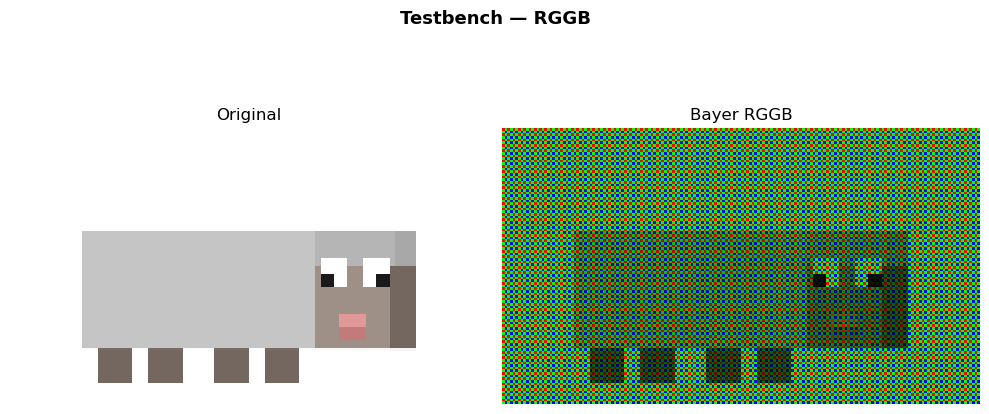

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Testbench — RGGB", fontsize=13, fontweight='bold')

axes[0].imshow(img, interpolation='nearest')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(mosaicos["RGGB"], interpolation='nearest')
axes[1].set_title("Bayer RGGB")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("bayer_RGGB.png", dpi=150, bbox_inches='tight')
plt.show()

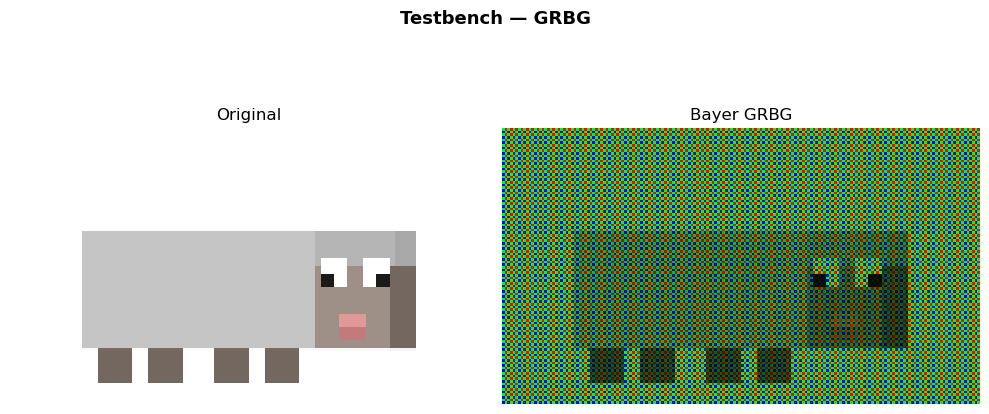

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Testbench — GRBG", fontsize=13, fontweight='bold')

axes[0].imshow(img, interpolation='nearest')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(mosaicos["GRBG"], interpolation='nearest')
axes[1].set_title("Bayer GRBG")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("bayer_GRBG.png", dpi=150, bbox_inches='tight')
plt.show()

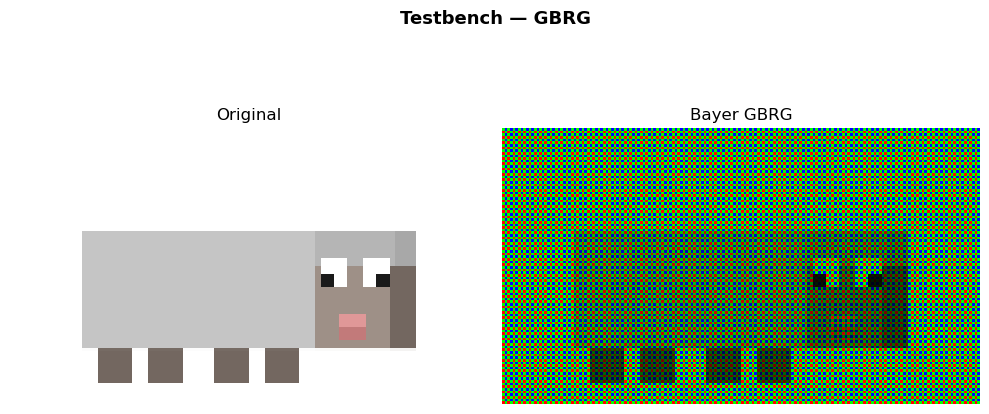

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Testbench — GBRG", fontsize=13, fontweight='bold')

axes[0].imshow(img, interpolation='nearest')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(mosaicos["GBRG"], interpolation='nearest')
axes[1].set_title("Bayer GBRG")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("bayer_GBRG.png", dpi=150, bbox_inches='tight')
plt.show()

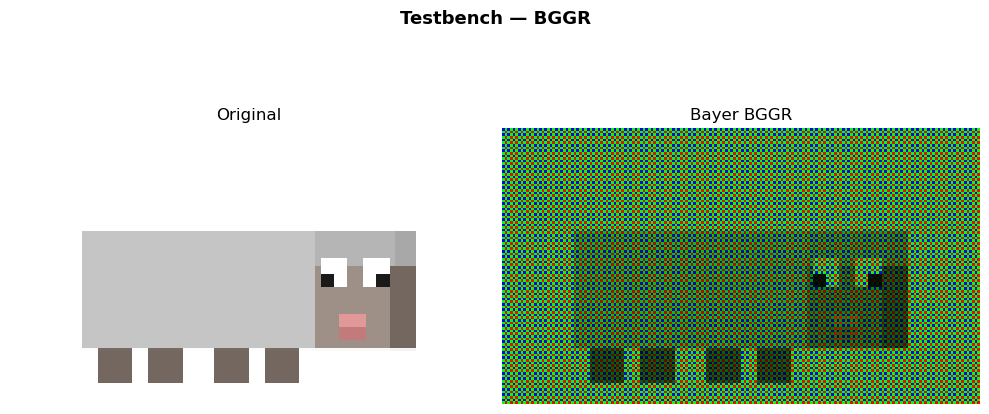

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Testbench — BGGR", fontsize=13, fontweight='bold')

axes[0].imshow(img, interpolation='nearest')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(mosaicos["BGGR"], interpolation='nearest')
axes[1].set_title("Bayer BGGR")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("bayer_BGGR.png", dpi=150, bbox_inches='tight')
plt.show()